# Netflix Data Visualization with Matplotlib and Seaborn

---

**ES**

# Visualización de datos de Netflix con Matplotlib y Seaborn

## Project Description
This project explores Netflix's content catalog using Python, Seaborn and Matplotlib to generate visualizations that help uncover trends related to the type of content. The data includes title, release year, type, genre, rating, number of votes, country, language, duration, and director.  The goal is to discover patterns and trends in the content available on the platform through visualizations and basic statistics.

---

**ES**

## Descripción del proyecto
Este proyecto explora el catálogo de contenido de Netflix usando Python, Seaborn y Matplotlib para generar visualizaciones que ayuden a descubrir tendencias relacionadas con el tipo de contenido. Los datos incluyen título, año de lanzamiento, tipo, género, rating, número de votos, país, idioma, duración y director. El objetivo es descubrir patrones y tendencias en el contenido disponible en la plataforma mediante visualizaciones y estadísticas básicas.

### Project Objectives

- Practice data visualization skills using Matplotlib and Seaborn.

- Gain insights into the distribution of Netflix content over time and across countries.

- Provide a visual reference that could inform marketing, production, or business strategy.

---

**ES**

### Objetivos del proyecto

- Practicar habilidades de visualización de datos con Matplotlib y Seaborn.

- Obtener información sobre la distribución del contenido de Netflix a lo largo del tiempo y entre países.

- Ofrecer una referencia visual que pueda orientar decisiones de marketing, producción o estrategia de negocio.

## Data Loading & Initial Exploration

---

**ES**

## Carga de datos y exploración inicial

In [52]:
# Import required libraries / ES: Importar las librerías necesarias

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns


I begin by importing the essential Python libraries for data analysis and visualization:

- **pandas**: for data manipulation and handling structured datasets.
- **numpy**: for numerical operations.
- **matplotlib.pyplot**: for creating visualizations.
- **seaborn**: for creating visualizations.

---

**ES**

Comienzo importando las librerías esenciales de Python para el análisis y la visualización de datos:

- **pandas**: para la manipulación de datos y el manejo de datasets estructurados.
- **numpy**: para operaciones numéricas.
- **matplotlib.pyplot**: para crear visualizaciones.
- **seaborn**: para crear visualizaciones.

In [53]:
# I load the Netflix dataset from an Excel file and define Netflix’s colors to maintain a consistent visual identity in our plots. / ES: Cargo el dataset de Netflix desde un archivo Excel y defino los colores de Netflix para mantener una identidad visual consistente en los gráficos.

df = pd.read_excel("data/Crehana - Netflix Dataset.xlsx")
color_Netflix ='#E50914'

# Define a Netflix‐inspired palette (Seaborn) / ES: Definir una paleta inspirada en Netflix (Seaborn)
color_netflix1 = {
    'movie': '#E50914',      # Netflix Red
    'series': '#221F1F',     # Netflix Black
    'mini series': '#B81D24',# Darker Red
    'short': '#7F7F7F'       # Neutral gray
}

color_netflix2 = {
    'Comedy':       '#E50914',  # Classic Netflix Red
    'Drama':        '#B81D24',  # Darker red accent
    'Action':       '#8B0000',  # Deep crimson
    'Documentary':  '#221F1F',  # Netflix Black
    'Animation':    '#F5F5F1',  # Very light gray (frame background)
    'Crime':        '#333333',  # Dark charcoal
    'Horror':       '#0B0A0A',  # Almost pure black
    'Musical':      '#FF4747',  # Bright red highlight
    'Adventure':    '#C60F13',  # Mid‐tone red
    'Short':        '#7F7F7F',  # Neutral gray
    'Fantasy':      '#D90D16',  # Slightly lighter red
    'Family':       '#F1F1F1',  # Soft off‐white
    'Sport':        '#555555',  # Medium gray
    'Mystery':      '#444444',  # Dark gray
    'Reality-TV':   '#CCCCCC'   # Light gray
}


color_netflix3 = {
    'mini series':       '#E50914',  # Classic Netflix Red
    'movie':        '#B81D24',  # Darker red accent
    'series':       '#333333',  # Dark charcoal
    'short':  '#221F1F',  # Netflix Black
}

In [54]:
# Let’s take an initial look at the dataset by checking its dimensions and displaying a random sample of 5 entries. / ES: Primer vistazo al dataset: revisamos sus dimensiones y mostramos una muestra aleatoria de 5 registros.

print("df Shape:",df.shape)
df.sample(5)

df Shape: (6546, 11)


,Unnamed: 0,titulo,año,tipo,genero,rating,votos,pais,idioma,duracion_minutos,director
5948,6325,Eve of Destruction,1991,movie,Action,49,2206,United States,English,NaN,Duncan Gibbins
4467,4798,In Like Flint,1967,movie,Action,62,5401,United States,English,NaN,Gordon Douglas
1327,1420,Die! Die! My Darling!,1965,movie,Horror,63,2435,United Kingdom,English,97.0,Silvio Narizzano
2696,2919,Pom Poko,1994,movie,Animation,73,27566,Japan,Japanese,119.0,Isao Takahata
3410,3677,Wild Things: Diamonds in the Rough,2005,movie,Crime,45,4812,United States,English,87.0,Jay Lowi


In [55]:
# Remove the 'Unnamed: 0' column created during import (it was just an id and is no longer needed) / ES: Eliminar la columna 'Unnamed: 0' creada durante la importación (era solo un id y ya no se necesita)

df = df.drop('Unnamed: 0', axis=1)
df

,titulo,año,tipo,genero,rating,votos,pais,idioma,duracion_minutos,director
0,Dinosaur Planet,2003,mini series,Documentary,77,474,United States,English,50.0,NaN
1,Character,2021,movie,Crime,83,46,Japan,Japanese,125.0,Akira Nagai
2,Get Up and Dance!,1994,movie,Family,81,18,United States,English,54.0,Steve Purcell
3,The Rise and Fall of El Chapo,2016,movie,Documentary,69,42,United States,English,85.0,NaN
4,8 Man,1992,movie,Action,55,93,Japan,Japanese,83.0,Yasuhiro Horiuchi
...,...,...,...,...,...,...,...,...,...,...
6541,Lightning Bug,2004,movie,Drama,65,1304,United States,English,NaN,Robert Hall
6542,Gattaca,1997,movie,Drama,78,289781,United States,English,NaN,Andrew Niccol
6543,Interiors,1978,movie,Drama,74,19143,United States,English,NaN,Woody Allen
6544,All Monsters Attack,1969,movie,Adventure,39,4384,Japan,Japanese,NaN,IshirÃ´ Honda


In [56]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6546 entries, 0 to 6545
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   titulo            6546 non-null   object 
 1   año               6546 non-null   int64  
 2   tipo              6546 non-null   str    
 3   genero            6546 non-null   str    
 4   rating            6546 non-null   int64  
 5   votos             6546 non-null   int64  
 6   pais              6546 non-null   str    
 7   idioma            6516 non-null   str    
 8   duracion_minutos  4179 non-null   float64
 9   director          5472 non-null   str    
dtypes: float64(1), int64(3), object(1), str(5)
memory usage: 511.5+ KB


There are 6,546 rows and 10 columns. And there are “Non-Null Count” highlights missing values in rating, duracion, and director, which we’ll address in the data cleaning stage.

duracion_minutos only has 4,179 non-null entries—there are ~2,367 missing durations to handle.

---

**ES**

Hay 6,546 filas y 10 columnas. El “Non-Null Count” resalta valores faltantes en rating, duracion y director, que abordaremos en la etapa de limpieza de datos.

duracion_minutos solo tiene 4,179 entradas no nulas: hay ~2,367 duraciones faltantes por manejar.

In [57]:
df.describe()

,año,rating,votos,duracion_minutos
count,6546.000000,6546.000000,6.546000e+03,4179.000000
mean,1992.703025,66.526123,1.922704e+04,98.982053
std,16.480044,13.040409,9.503836e+04,68.005480
min,1914.000000,12.000000,5.000000e+00,2.000000
25%,1987.000000,60.000000,2.760000e+02,75.000000
50%,1998.000000,68.000000,1.421500e+03,93.000000
75%,2003.000000,76.000000,6.799750e+03,109.000000
max,2021.000000,93.000000,2.462087e+06,1620.000000


The mean release year is 1992, with a median (50%) of 1998, so half the titles are from 1998 or earlier.

The min/max release years span 1914 to 2021.

Ratings range from 12 to 93.

Votes go from as few as 5 to over 2.46 million (highly popular titles).

Durations run from 2 min up to 1,620 min (likely miniseries)

---

**ES**

El año promedio de lanzamiento es 1992, con una mediana (50%) de 1998, así que la mitad de los títulos son de 1998 o antes.

El año mínimo/máximo de lanzamiento va de 1914 a 2021.

Los ratings van de 12 a 93.

Los votos van desde apenas 5 hasta más de 2.46 millones (títulos muy populares).

Las duraciones van desde 2 min hasta 1,620 min (probablemente miniseries)

## Data Cleaning & Preprocessing

---

**ES**

## Limpieza y preprocesamiento de datos

In [58]:
# Check how many duplicate rows exist (exact matches across all columns) / ES: Verificar cuántas filas duplicadas existen (coincidencias exactas en todas las columnas)

df.duplicated().sum()

np.int64(195)

In [59]:
# Remove duplicates, keeping the first occurrence / ES: Eliminar duplicados, conservando la primera aparición

df = df.drop_duplicates(keep='first').reset_index(drop=True)
df.duplicated().sum()


np.int64(0)

In [60]:
# Inspect how many values are missing in each column / ES: Revisar cuántos valores faltan en cada columna

print(df[['duracion_minutos', 'director']].isna().sum())


duracion_minutos    2323
director             950
dtype: int64


### Missing values in duracion_minutos

---

**ES**

### Valores faltantes en duracion_minutos

In [61]:
# Compute median duration per genre / ES: Calcular la duración mediana por género

genre_median = df.groupby('genero')['duracion_minutos'].median()
genre_median

genero
Action          99.0
Adventure       96.0
Animation       51.0
Comedy          95.0
Crime           98.0
Documentary     90.0
Drama          101.0
Family          56.0
Fantasy         93.5
Horror          91.0
Musical         93.0
Mystery         90.0
Reality-TV      50.0
Short           26.0
Sport          172.0
Name: duracion_minutos, dtype: float64

In [62]:
# Create a new column by mapping each row’s genre to its median / ES: Crear una nueva columna mapeando el género de cada fila a su mediana

df['duracion_fill_genre'] = df['genero'].map(genre_median)
df

,titulo,año,tipo,genero,rating,votos,pais,idioma,duracion_minutos,director,duracion_fill_genre
0,Dinosaur Planet,2003,mini series,Documentary,77,474,United States,English,50.0,NaN,90.0
1,Character,2021,movie,Crime,83,46,Japan,Japanese,125.0,Akira Nagai,98.0
2,Get Up and Dance!,1994,movie,Family,81,18,United States,English,54.0,Steve Purcell,56.0
3,The Rise and Fall of El Chapo,2016,movie,Documentary,69,42,United States,English,85.0,NaN,90.0
4,8 Man,1992,movie,Action,55,93,Japan,Japanese,83.0,Yasuhiro Horiuchi,99.0
...,...,...,...,...,...,...,...,...,...,...,...
6346,Lightning Bug,2004,movie,Drama,65,1304,United States,English,NaN,Robert Hall,101.0
6347,Gattaca,1997,movie,Drama,78,289781,United States,English,NaN,Andrew Niccol,101.0
6348,Interiors,1978,movie,Drama,74,19143,United States,English,NaN,Woody Allen,101.0
6349,All Monsters Attack,1969,movie,Adventure,39,4384,Japan,Japanese,NaN,IshirÃ´ Honda,96.0


In [63]:
# Fill NaNs in the original duration with the genre-specific median / ES: Rellenar los NaN de la duración original con la mediana específica del género

df['duracion_minutos'] = df['duracion_minutos'].fillna(df['duracion_fill_genre'])

# Drop the helper column / ES: Eliminar la columna auxiliar
df = df.drop(columns=['duracion_fill_genre'])

df

,titulo,año,tipo,genero,rating,votos,pais,idioma,duracion_minutos,director
0,Dinosaur Planet,2003,mini series,Documentary,77,474,United States,English,50.0,NaN
1,Character,2021,movie,Crime,83,46,Japan,Japanese,125.0,Akira Nagai
2,Get Up and Dance!,1994,movie,Family,81,18,United States,English,54.0,Steve Purcell
3,The Rise and Fall of El Chapo,2016,movie,Documentary,69,42,United States,English,85.0,NaN
4,8 Man,1992,movie,Action,55,93,Japan,Japanese,83.0,Yasuhiro Horiuchi
...,...,...,...,...,...,...,...,...,...,...
6346,Lightning Bug,2004,movie,Drama,65,1304,United States,English,101.0,Robert Hall
6347,Gattaca,1997,movie,Drama,78,289781,United States,English,101.0,Andrew Niccol
6348,Interiors,1978,movie,Drama,74,19143,United States,English,101.0,Woody Allen
6349,All Monsters Attack,1969,movie,Adventure,39,4384,Japan,Japanese,96.0,IshirÃ´ Honda


In [64]:
print(df[['duracion_minutos', 'director']].isna().sum())


duracion_minutos      0
director            950
dtype: int64


I fill in missing duracion_minutos using each genre’s “middle” value (the median) because it’s a good stand-in for a “typical” length without letting a handful of very long or very short titles pull the number way up or down.

Why by genre? A comedy’s normal length is very different from a documentary’s or a Reality TV, so we compute the median for each specific group.

Why the median? Unlike the average, the median isn’t dragged around by extreme outliers, so it gives us a stable, representative fill-in that keeps the stats more reliable.

---

**ES**

Relleno los valores faltantes de duracion_minutos usando el valor “central” de cada género (la mediana), porque es un buen sustituto de una duración “típica” sin que unos pocos títulos muy largos o muy cortos alteren demasiado el número.

¿Por qué por género? La duración normal de una comedia es muy distinta a la de un documental o un Reality TV, así que calculamos la mediana para cada grupo específico.

¿Por qué la mediana? A diferencia del promedio, la mediana no se ve arrastrada por valores atípicos extremos, así que nos da un relleno estable y representativo que mantiene las estadísticas más confiables.

### Missing values in director

---

**ES**

### Valores faltantes en director

In [65]:
# Fill missing entries with a placeholder so rows are preserved / ES: Rellenar los valores faltantes con un marcador para conservar las filas

df['director'] = df['director'].fillna('Unknown')


950 rows had no director listed

By filling those with a placeholder like "Unknown" instead of dropping them we preserves records.

---

**ES**

950 filas no tenían director registrado.

Al rellenarlas con un marcador como "Unknown" en lugar de eliminarlas, conservamos los registros.

In [66]:
# Confirmation that there is no missing values / ES: Confirmación de que ya no hay valores faltantes

print(df[['duracion_minutos', 'director']].isna().sum())


duracion_minutos    0
director            0
dtype: int64


## Exploratory Data Analysis (EDA)

---

**ES**

## Análisis exploratorio de datos (EDA)

In [67]:
df

,titulo,año,tipo,genero,rating,votos,pais,idioma,duracion_minutos,director
0,Dinosaur Planet,2003,mini series,Documentary,77,474,United States,English,50.0,Unknown
1,Character,2021,movie,Crime,83,46,Japan,Japanese,125.0,Akira Nagai
2,Get Up and Dance!,1994,movie,Family,81,18,United States,English,54.0,Steve Purcell
3,The Rise and Fall of El Chapo,2016,movie,Documentary,69,42,United States,English,85.0,Unknown
4,8 Man,1992,movie,Action,55,93,Japan,Japanese,83.0,Yasuhiro Horiuchi
...,...,...,...,...,...,...,...,...,...,...
6346,Lightning Bug,2004,movie,Drama,65,1304,United States,English,101.0,Robert Hall
6347,Gattaca,1997,movie,Drama,78,289781,United States,English,101.0,Andrew Niccol
6348,Interiors,1978,movie,Drama,74,19143,United States,English,101.0,Woody Allen
6349,All Monsters Attack,1969,movie,Adventure,39,4384,Japan,Japanese,96.0,IshirÃ´ Honda


### Content Production Over Time

---

**ES**

### Producción de contenido a lo largo del tiempo

In [68]:
# Number of titles released per year. / ES: Número de títulos lanzados por año.

titles_per_year = df['año'].value_counts().sort_index()
titles_per_year

año
1914     1
1916     1
1918     2
1919     1
1923     1
        ..
2017    34
2018    37
2019    36
2020    50
2021    44
Name: count, Length: 103, dtype: int64

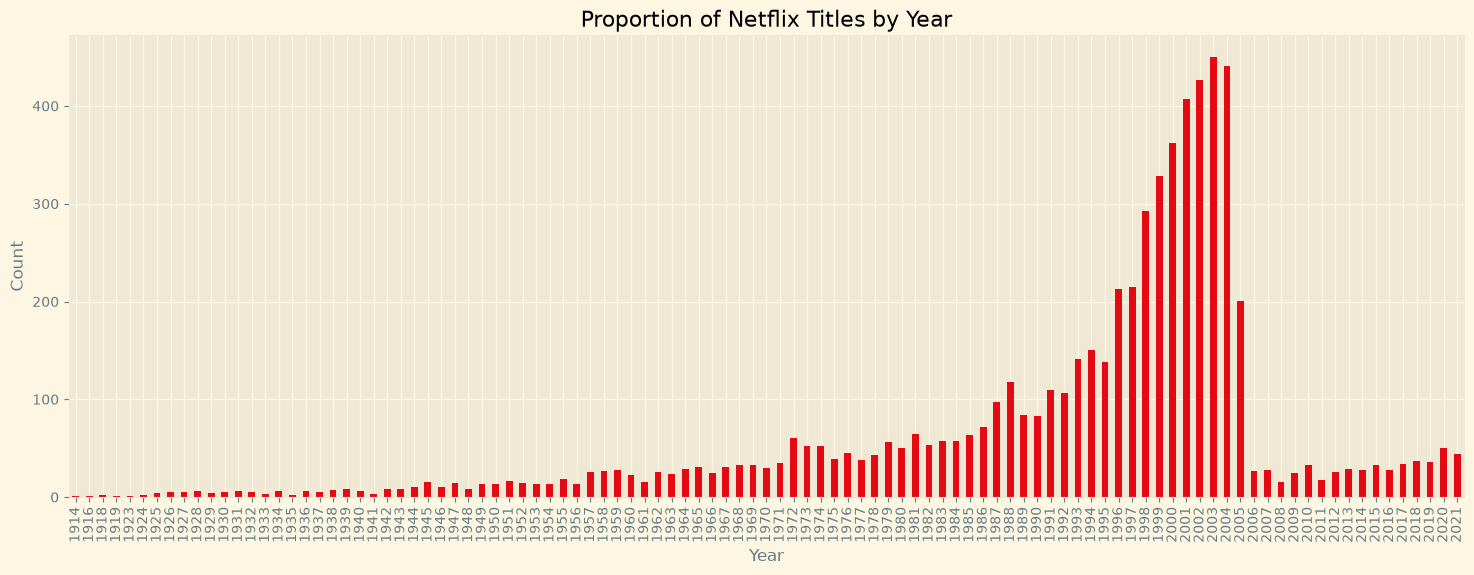

In [69]:
# I create a bar chart to visualize the titles across years. / ES: Creo un gráfico de barras para visualizar los títulos a lo largo de los años.

plt.style.use('Solarize_Light2')
plt.figure(figsize = (18, 6))

titles_per_year.plot(kind = 'bar',color=color_Netflix)
plt.title('Proportion of Netflix Titles by Year')
plt.ylabel('Count')
plt.xlabel('Year')
plt.xticks(rotation = 90)
plt.show()

There is a significant concentration of titles released between 1995 and 2002, peaking around 2002 with over 450 titles

After 2002, there is a sharp decline in the number of titles per year, followed by a moderate resurgence starting around 2010, likely reflecting the rise of Netflix Originals and newer acquisitions.

This distribution highlights Netflix’s emphasis on modern entertainment, with a particular abundance of titles from the late 1990s and early 2000s.

---

**ES**

Hay una concentración importante de títulos lanzados entre 1995 y 2002, con un pico alrededor de 2002 con más de 450 títulos.

Después de 2002 hay una caída pronunciada en el número de títulos por año, seguida de un repunte moderado a partir de 2010 aproximadamente, probablemente reflejando el auge de los Netflix Originals y nuevas adquisiciones.

Esta distribución resalta el énfasis de Netflix en el entretenimiento moderno, con una abundancia particular de títulos de finales de los 90 y principios de los 2000.

In [70]:
# Count titles for each content type / ES: Contar títulos por cada tipo de contenido

df['tipo'].value_counts().sort_index()

tipo
mini series     198
movie          5603
series          539
short            11
Name: count, dtype: int64

In [71]:
# Count titles per year for each content type / ES: Contar títulos por año para cada tipo de contenido

year_type_counts = (df.groupby(['año', 'tipo'])['titulo'].count())
year_type_counts

año   tipo       
1914  movie           1
1916  movie           1
1918  movie           2
1919  movie           1
1923  movie           1
                     ..
2020  movie          30
      series         18
2021  mini series     4
      movie          26
      series         14
Name: titulo, Length: 222, dtype: int64

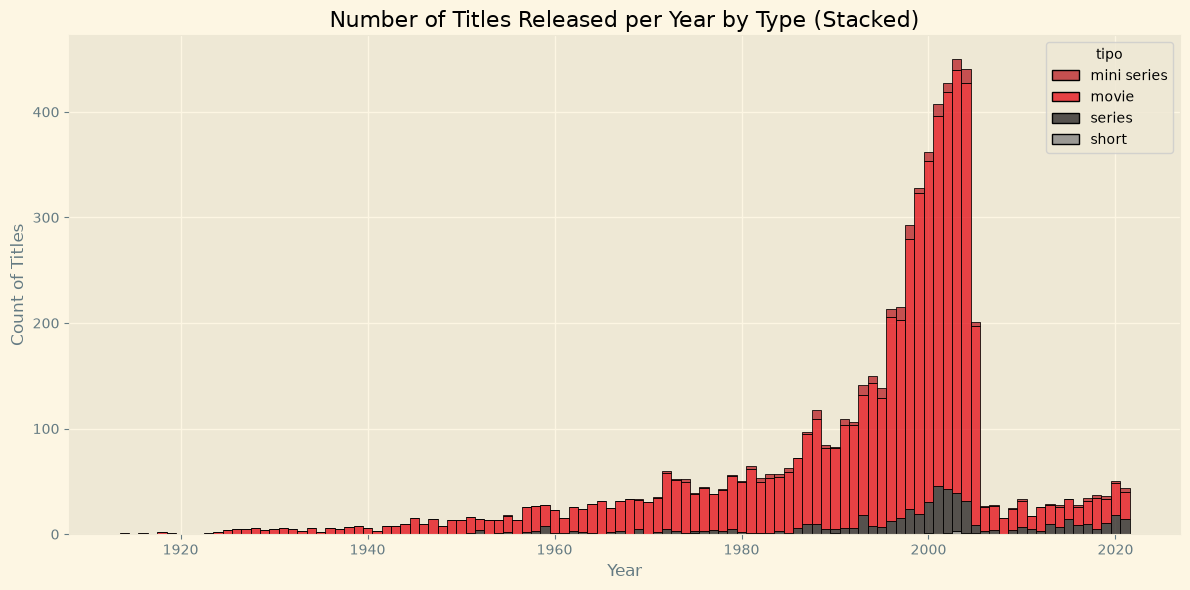

In [72]:
# Stacked bar for each content type / ES: Barra apilada por cada tipo de contenido

plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='año',hue='tipo',multiple='stack', discrete=True, palette=color_netflix1)

plt.title('Number of Titles Released per Year by Type (Stacked)')
plt.xlabel('Year')
plt.ylabel('Count of Titles')
plt.tight_layout()
plt.show()

Netflix has historically prioritized films over other content types.

The majority of titles across all years are movies (red bars), especially during the peak years from 1995 to 2002, when the number of releases per year exceeded 400 titles.

From 2000 onward, there's a noticeable rise in series.

Although they are still a smaller portion compared to movies, their presence grows consistently in the 2010s, likely driven by the rise of Netflix Originals and demand for episodic content.

---

**ES**

Netflix históricamente ha priorizado las películas sobre otros tipos de contenido.

La mayoría de los títulos en todos los años son películas (barras rojas), especialmente durante los años pico de 1995 a 2002, cuando el número de lanzamientos por año superó los 400 títulos.

A partir de 2000 hay un aumento notable en las series.

Aunque siguen siendo una porción menor comparadas con las películas, su presencia crece de forma constante en la década de 2010, probablemente impulsada por el auge de los Netflix Originals y la demanda de contenido episódico.

### Genre Trends

---

**ES**

### Tendencias por género

In [73]:
# The `value_counts()` method to find out how many titles belong to each genre. This helps us understand the most common types of content available on Netflix. / ES: El método `value_counts()` para saber cuántos títulos pertenecen a cada género. Esto nos ayuda a entender los tipos de contenido más comunes disponibles en Netflix.

titulos_por_genero = df["genero"].value_counts()
titulos_por_genero

genero
Comedy         1226
Documentary    1179
Drama          1161
Action          862
Animation       632
Crime           324
Horror          275
Musical         226
Adventure       185
Short            87
Fantasy          59
Family           54
Sport            34
Mystery          27
Reality-TV       20
Name: count, dtype: int64

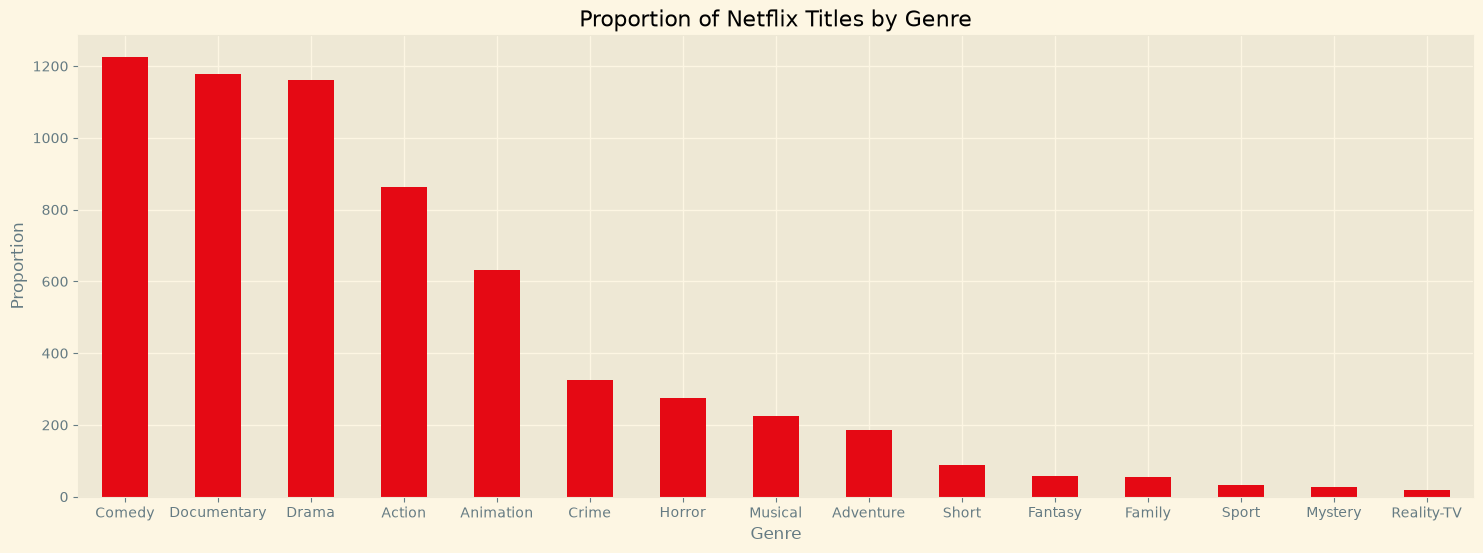

In [74]:
#We create a bar chart to visualize the proportion of titles across different genres. / ES: Creamos un gráfico de barras para visualizar la proporción de títulos entre los distintos géneros.

plt.style.use('Solarize_Light2')
plt.figure(figsize = (18, 6))

titulos_por_genero.plot(kind = 'bar',color=color_Netflix)
plt.title('Proportion of Netflix Titles by Genre')
plt.ylabel('Proportion')
plt.xlabel('Genre')
plt.xticks(rotation = 0)
plt.show()

Comedy, Documentary, and Drama are the dominant genres in Netflix’s library, each with more than 1,100 titles.

Mid-level genres like Action, Animation, and Crime also play a significant role, while categories such as Reality-TV, Sport, and Mystery are minimally represented.

---

**ES**

Comedy, Documentary y Drama son los géneros dominantes en la biblioteca de Netflix, cada uno con más de 1,100 títulos.

Géneros de nivel medio como Action, Animation y Crime también tienen un papel importante, mientras que categorías como Reality-TV, Sport y Mystery están mínimamente representadas.

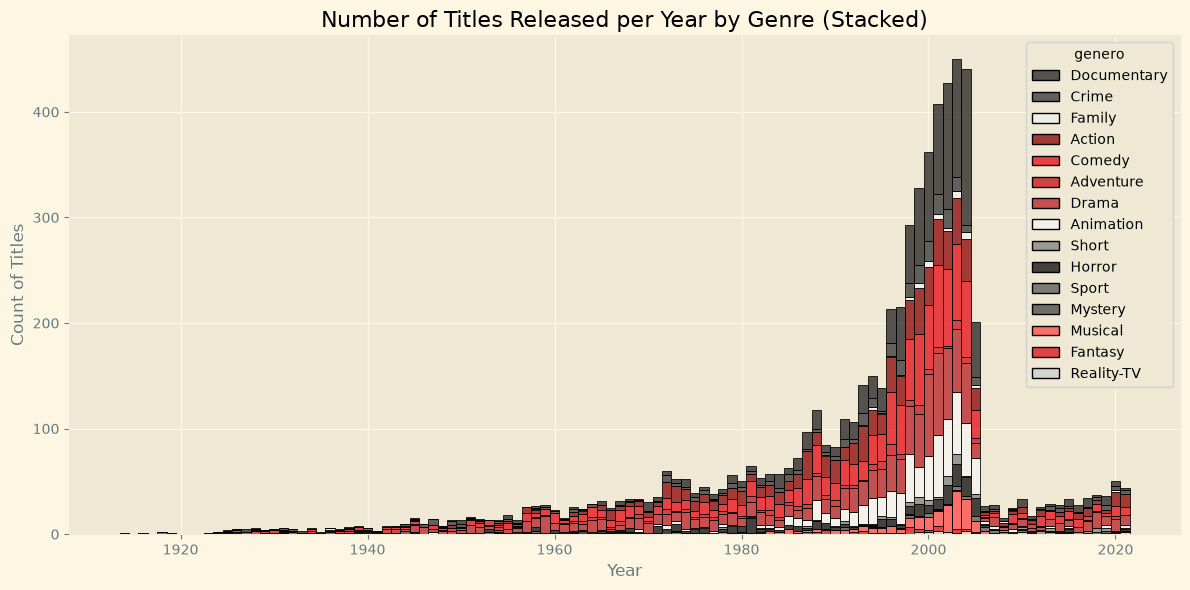

In [75]:
# Stacked bar for each genre type / ES: Barra apilada por tipo de género

plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='año',hue='genero',multiple='stack', discrete=True, palette = color_netflix2)

plt.title('Number of Titles Released per Year by Genre (Stacked)')
plt.xlabel('Year')
plt.ylabel('Count of Titles')
plt.tight_layout()
plt.show()

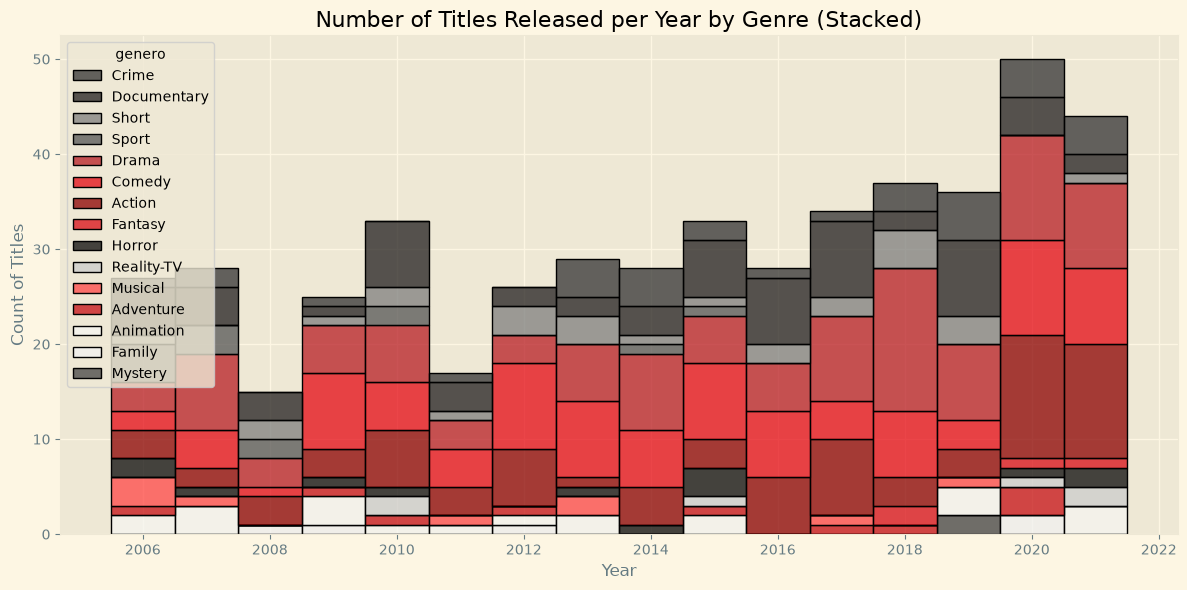

In [76]:
# This preparation will allow us to visualize content production for the recent years. / ES: Esta preparación nos permitirá visualizar la producción de contenido de los años recientes.

recent_df = df[df['año'] > 2005]
recent_df

# Stacked bar for each genre type / ES: Barra apilada por tipo de género

plt.figure(figsize=(12, 6))
sns.histplot(data=recent_df, x='año',hue='genero',multiple='stack', discrete=True, palette = color_netflix2)

plt.title('Number of Titles Released per Year by Genre (Stacked)')
plt.xlabel('Year')
plt.ylabel('Count of Titles')
plt.tight_layout()
plt.show()

In recent years, although fewer titles are released annually, there is a greater variety of genres, indicating Netflix’s shift toward a more diversified and globally appealing catalog.

---

**ES**

En los últimos años, aunque se lanzan menos títulos anualmente, hay una mayor variedad de géneros, lo que indica el giro de Netflix hacia un catálogo más diversificado y con atractivo global.

### Rating and Votes

---

**ES**

### Rating y votos

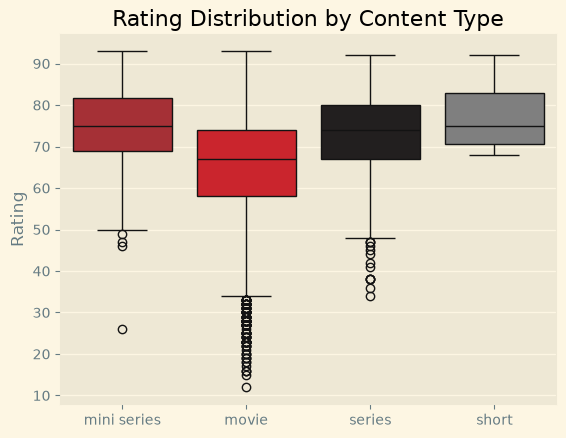

In [77]:
# Boxplots: rating distribution by type. / ES: Boxplots: distribución del rating por tipo.

sns.boxplot(data=df, x = 'tipo', hue='tipo', y='rating', palette=color_netflix1)
plt.title('Rating Distribution by Content Type')
plt.xlabel('')
plt.ylabel('Rating')
plt.show()

The boxplot shows that shorts and mini series tend to receive the highest and most consistent ratings on Netflix, while movies exhibit the greatest variability, including many low-rated titles. Series also maintain strong median ratings, though with a slightly wider range than shorts or mini series. This suggests that while movies dominate in volume, they are less predictable in quality, whereas short-form and episodic content may offer more consistent viewer satisfaction.

---

**ES**

El boxplot muestra que los shorts y las mini series tienden a recibir los ratings más altos y consistentes en Netflix, mientras que las películas muestran la mayor variabilidad, incluyendo muchos títulos con ratings bajos. Las series también mantienen ratings medianos sólidos, aunque con un rango ligeramente más amplio que los shorts o las mini series. Esto sugiere que, si bien las películas dominan en volumen, son menos predecibles en calidad, mientras que el contenido corto y episódico podría ofrecer una satisfacción del espectador más consistente.

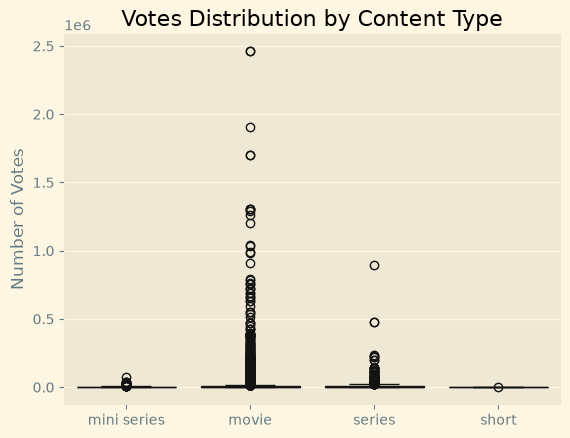

In [78]:
# Boxplots: Votes by content type / ES: Boxplots: votos por tipo de contenido

sns.boxplot(data=df, x='tipo', hue='tipo', y='votos', palette=color_netflix1)
plt.title('Votes Distribution by Content Type')
plt.xlabel('')
plt.ylabel('Number of Votes')
plt.show()

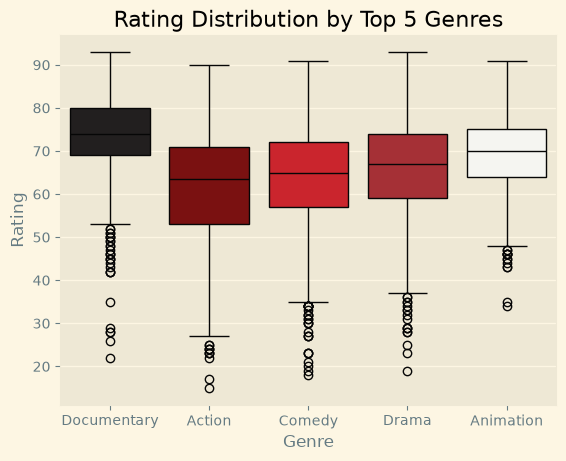

In [79]:
df_top5_genres = df[df['genero'].isin(['Comedy', 'Documentary', 'Drama', 'Action', 'Animation'])]
df_top5_genres

                                    
# Rating by top-5 genres / ES: Rating de los 5 géneros principales

sns.boxplot(data=df_top5_genres, x = 'genero', hue='genero', y='rating', palette=color_netflix2)
plt.title('Rating Distribution by Top 5 Genres')
plt.xlabel('Genre')
plt.ylabel('Rating')
plt.show()

This chart shows that Documentary and Animation titles tend to receive the most consistently high ratings on Netflix, with fewer low-performing titles. In contrast, Action, Comedy, and Drama—despite being popular genres—exhibit a wider spread in viewer ratings, including a notable number of low-rated titles. This suggests that while fiction genres dominate in volume, non-fiction and animated content may deliver more consistently positive viewer experiences.

---

**ES**

Este gráfico muestra que los títulos de Documentary y Animation tienden a recibir los ratings más altos y consistentes en Netflix, con menos títulos de bajo desempeño. En contraste, Action, Comedy y Drama —a pesar de ser géneros populares— muestran una dispersión más amplia en los ratings, incluyendo un número notable de títulos con rating bajo. Esto sugiere que, si bien los géneros de ficción dominan en volumen, el contenido de no ficción y animado podría ofrecer experiencias más consistentemente positivas para el espectador.

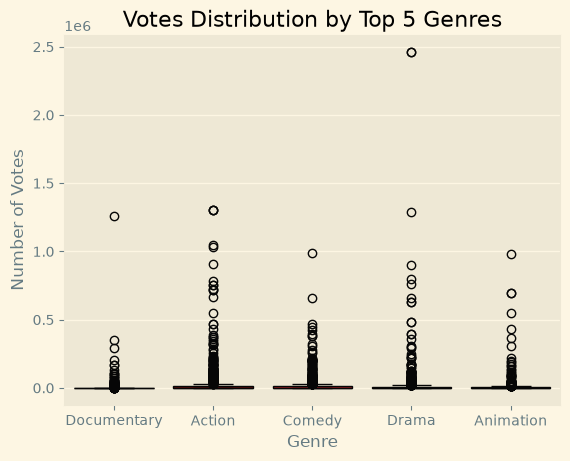

In [80]:
# Votes by top-5 genres / ES: Votos de los 5 géneros principales

sns.boxplot(data=df_top5_genres, x='genero', hue='genero',  y='votos', palette=color_netflix2)
plt.title('Votes Distribution by Top 5 Genres')
plt.xlabel('Genre')
plt.ylabel('Number of Votes')
plt.show()

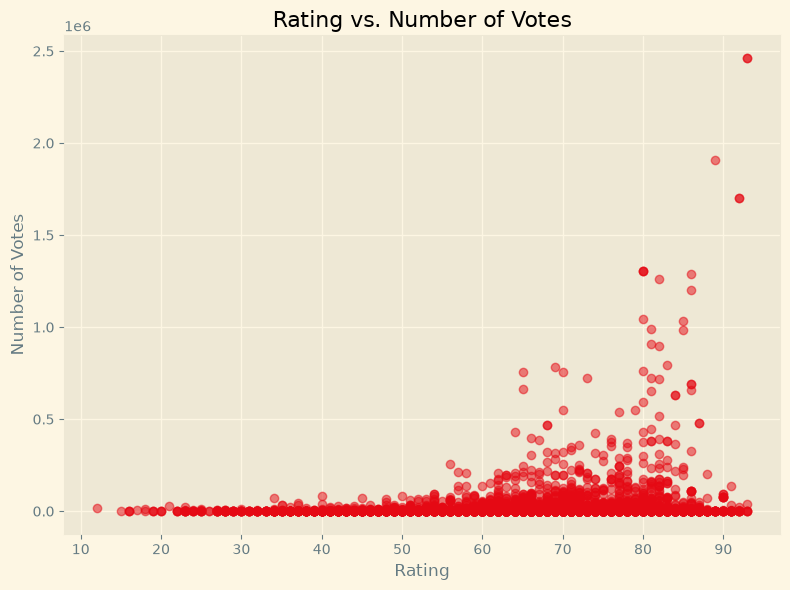

In [81]:
# Scatter plot: rating vs number of votes / ES: Diagrama de dispersión: rating vs número de votos

plt.figure(figsize=(8, 6))
plt.scatter(df['rating'], df['votos'], alpha=0.5, color =color_Netflix )
plt.title('Rating vs. Number of Votes')
plt.xlabel('Rating')
plt.ylabel('Number of Votes')
plt.grid(True)
plt.tight_layout()
plt.show()


The majority of titles receive relatively few votes, suggesting limited audience exposure.

There are also many well-rated titles with low vote counts, highlighting that quality does not always equate to popularity.

Audience attention naturally gravitates toward higher-quality productions.

---

**ES**

La mayoría de los títulos reciben relativamente pocos votos, lo que sugiere una exposición limitada ante la audiencia.

También hay muchos títulos bien calificados con pocos votos, lo que resalta que la calidad no siempre equivale a popularidad.

La atención de la audiencia gravita naturalmente hacia producciones de mayor calidad.

### Duration Analysis

---

**ES**

### Análisis de duración

In [82]:
# Preparing data filtered by tipo / ES: Preparando los datos filtrados por tipo

mini_series_df = df[df['tipo'].isin(['mini series'])]
movie_df = df[df['tipo'].isin(['movie'])]
series_df = df[df['tipo'].isin(['series'])]
short_df =  df[df['tipo'].isin(['short'])]


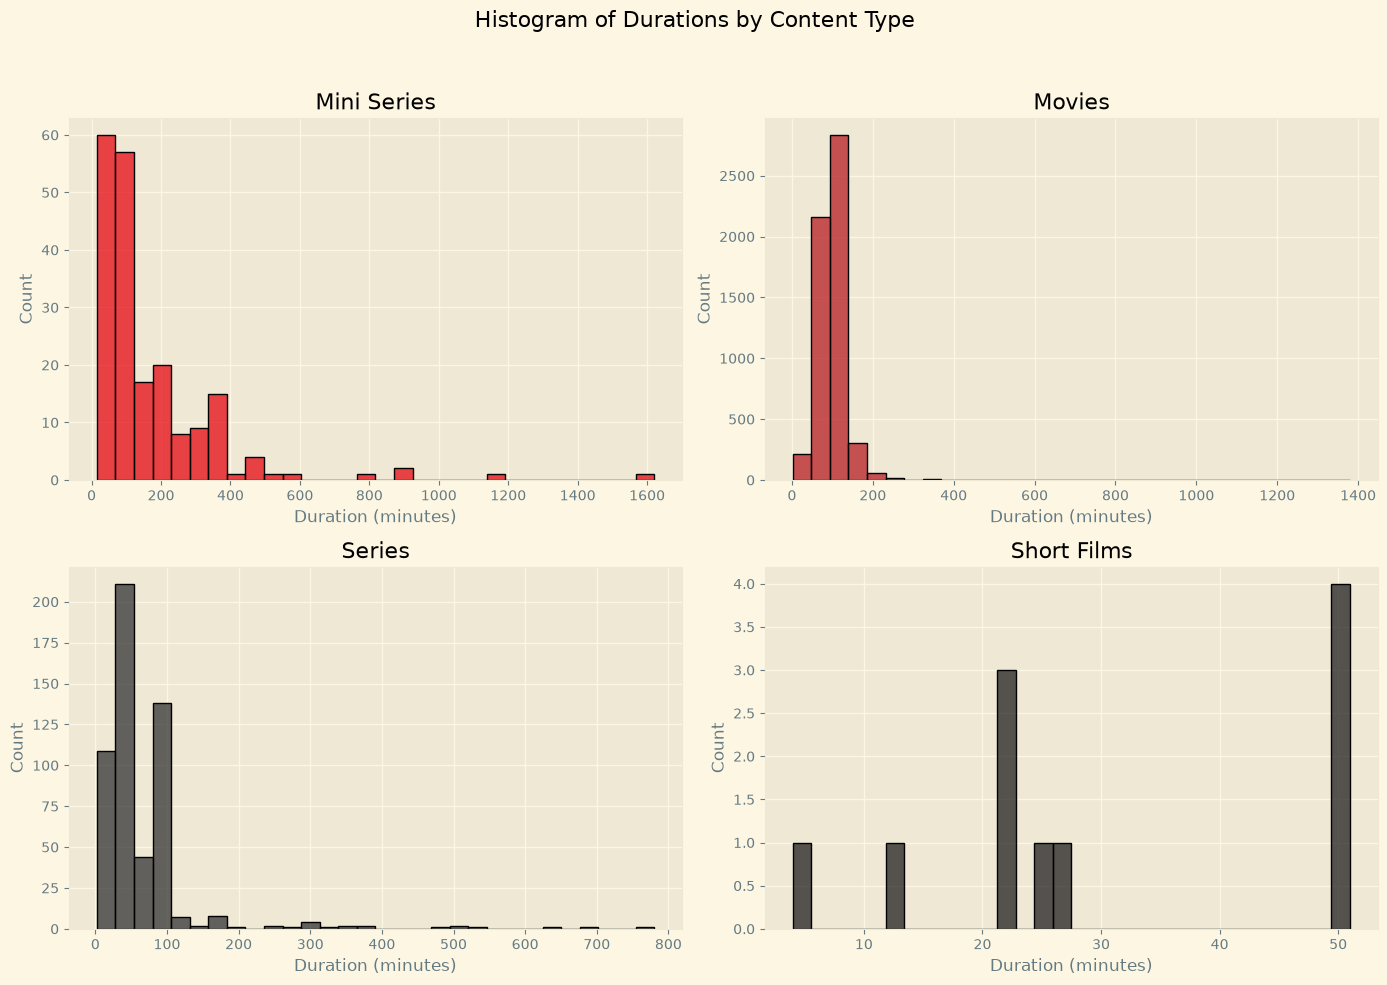

In [83]:
# Histogram of durations by tipos. / ES: Histograma de duraciones por tipo.


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Histogram of Durations by Content Type', fontsize=16)


# Mini Series / ES: Mini Series / Miniseries
sns.histplot(
    data=mini_series_df,
    x='duracion_minutos',
    bins=30,
    color= color_netflix3['mini series'],
    ax=axes[0, 0]
)
axes[0, 0].set_title('Mini Series')
axes[0, 0].set_xlabel('Duration (minutes)')
axes[0, 0].set_ylabel('Count')

# Movie / ES: Movie / Película
sns.histplot(
    data=movie_df,
    x='duracion_minutos',
    bins=30,
    color= color_netflix3['movie'],
    ax=axes[0, 1]
)
axes[0, 1].set_title('Movies')
axes[0, 1].set_xlabel('Duration (minutes)')
axes[0, 1].set_ylabel('Count')

# Series / ES: Series / Series
sns.histplot(
    data=series_df,
    x='duracion_minutos',
    bins=30,
    color= color_netflix3['series'],
    ax=axes[1, 0]
)
axes[1, 0].set_title('Series')
axes[1, 0].set_xlabel('Duration (minutes)')
axes[1, 0].set_ylabel('Count')

# Short / ES: Short / Cortometraje
sns.histplot(
    data=short_df,
    x='duracion_minutos',
    bins=30,
    color= color_netflix3['short'],
    ax=axes[1, 1]
)
axes[1, 1].set_title('Short Films')
axes[1, 1].set_xlabel('Duration (minutes)')
axes[1, 1].set_ylabel('Count')

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for the main title
plt.show()

There are a clear distinctions in duration patterns by content type.

Movies and short films follow traditional runtime expectations, with movies clustering tightly around 90–120 minutes and shorts under 50 minutes. Mini series and series, on the other hand, show greater variability

---

**ES**

Hay distinciones claras en los patrones de duración según el tipo de contenido.

Las películas y los cortometrajes siguen las expectativas tradicionales de duración, con las películas concentradas entre 90 y 120 minutos y los shorts por debajo de 50 minutos. Las mini series y las series, en cambio, muestran mayor variabilidad.

### Content by Country and Language

---

**ES**

### Contenido por país e idioma

In [84]:
# Top 5 countries with most titles. / ES: Top 5 países con más títulos.
top5_countries = df['pais'].value_counts().head(5)
top5_countries


pais
United States     3692
United Kingdom     634
Japan              569
India              262
Canada             211
Name: count, dtype: int64

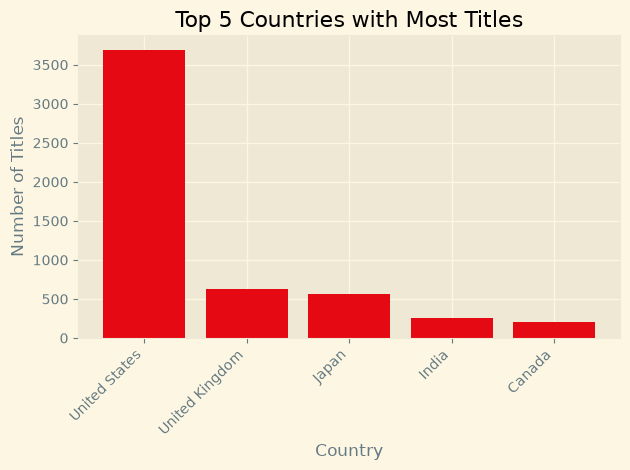

In [85]:
#Plot as a bar chart / ES: Graficar como un gráfico de barras

plt.bar(
    top5_countries.index,
    top5_countries.values, color = color_Netflix)

plt.title('Top 5 Countries with Most Titles')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This chart reveals that Netflix’s catalog is heavily dominated by U.S produced content, with over 3,500 titles from the United States. The United Kingdom and Japan contribute moderately, while India and Canada follow with smaller yet notable amounts.

---

**ES**

Este gráfico revela que el catálogo de Netflix está fuertemente dominado por contenido producido en EE. UU., con más de 3,500 títulos provenientes de Estados Unidos. El Reino Unido y Japón contribuyen de forma moderada, mientras que India y Canadá les siguen con cantidades menores pero notables.

In [86]:
# Top 5 languages with most titles. / ES: Top 5 idiomas con más títulos.

top5_languages = df['idioma'].value_counts().head(5)
top5_languages

idioma
English      4708
Japanese      507
Hindi         236
Cantonese     189
French        171
Name: count, dtype: int64

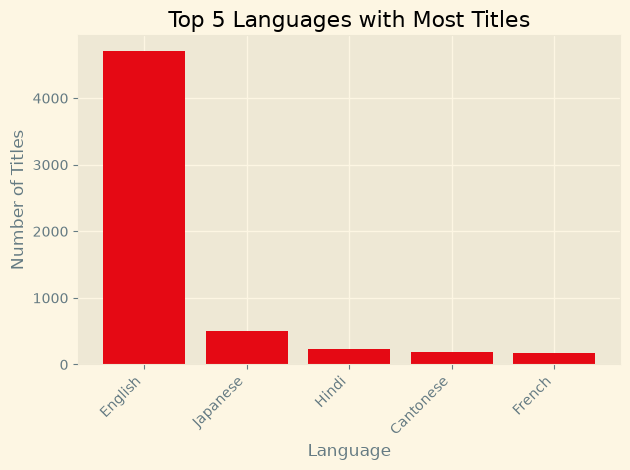

In [87]:
# Language distribution. / ES: Distribución por idioma.

plt.bar(
    top5_languages.index,
    top5_languages.values, color = color_Netflix)

plt.title('Top 5 Languages with Most Titles')
plt.xlabel('Language')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


This chart emphasizes that English dominates Netflix’s content.

This imbalance reflects Netflix’s strong foundation in English-speaking markets. Although the presence of multiple non-English languages signals an effort to diverse global audiences.

---

**ES**

Este gráfico resalta que el inglés domina el contenido de Netflix.

Este desequilibrio refleja la fuerte base de Netflix en los mercados de habla inglesa. Aunque la presencia de múltiples idiomas no ingleses señala un esfuerzo por diversificar las audiencias globales.

In [88]:
# Most common genres overall. / ES: Géneros más comunes en general.

top5_countries = top5_countries.reset_index()
top5_countries = top5_countries['pais'].tolist()

top5_countries = df[df['pais'].isin(top5_countries)]


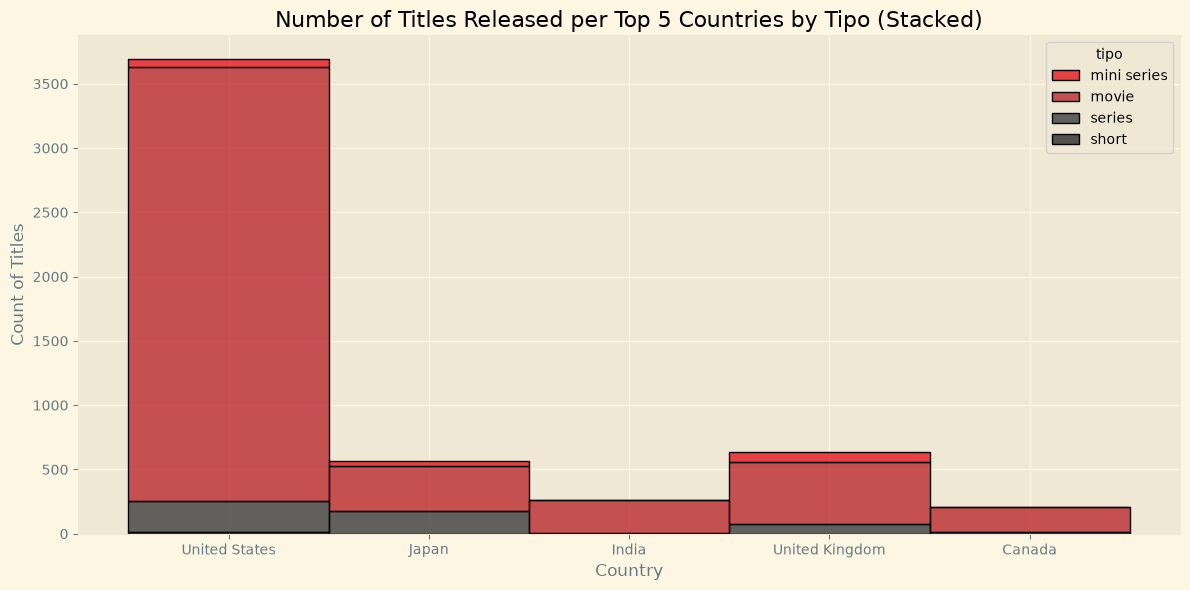

In [89]:
# Stacked bar for each country and type / ES: Barra apilada por país y tipo

plt.figure(figsize=(12, 6))
sns.histplot(data=top5_countries, x='pais',hue='tipo',multiple='stack', discrete=True, palette = color_netflix3)

plt.title('Number of Titles Released per Top 5 Countries by Tipo (Stacked)')
plt.xlabel('Country')
plt.ylabel('Count of Titles')
plt.tight_layout()
plt.show()

United States not only leads in total Netflix content but also shows a strong presence across all content types, especially movies.

United Kingdom and Japan show more genre diversity with visible contributions from series and mini series. India and Canada, by contrast, produce far fewer titles, mostly focusing on movies.

---

**ES**

Estados Unidos no solo lidera el contenido total de Netflix, sino que también muestra una fuerte presencia en todos los tipos de contenido, especialmente películas.

El Reino Unido y Japón muestran mayor diversidad de géneros con contribuciones visibles de series y mini series. India y Canadá, en cambio, producen muchos menos títulos, enfocados principalmente en películas.

### Most Active Directors

---

**ES**

### Directores más activos

In [90]:
# Top 10 directors by number of titles. / ES: Top 10 directores por número de títulos.

top10_directors_movies = df[~df['director'].isin(['Unknown'])]
top10_directors_movies = top10_directors_movies['director'].value_counts().head(10)


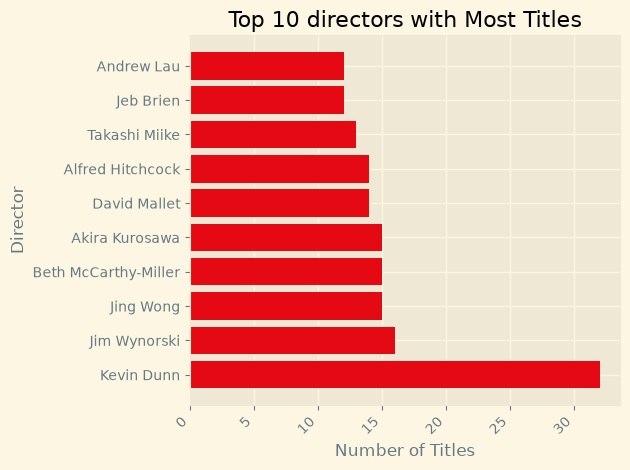

In [91]:
plt.barh(
    top10_directors_movies.index,
    top10_directors_movies.values, color = color_Netflix)

plt.title('Top 10 directors with Most Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Director')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Kevin Dunn is the most featured director on Netflix, with over 30 titles to his name, more than double the number of any other director on the list. The rest of the top 10 includes prominent figures like Akira Kurosawa, Alfred Hitchcock, and Jim Wynorski, each with between 13 and 17 titles. These directors represent a range of genres and international backgrounds

---

**ES**

Kevin Dunn es el director con más presencia en Netflix, con más de 30 títulos a su nombre, más del doble que cualquier otro director de la lista. El resto del top 10 incluye figuras destacadas como Akira Kurosawa, Alfred Hitchcock y Jim Wynorski, cada uno con entre 13 y 17 títulos. Estos directores representan una variedad de géneros y trayectorias internacionales.

In [92]:
# List of directors with more movies / ES: Lista de directores con más películas

top10_directors_movies = top10_directors_movies.reset_index()
top10_directors_movies = top10_directors_movies['director'].tolist()

In [93]:
# Creating a top 10 directors dataframe / ES: Creando un dataframe con el top 10 de directores
top10_directors_movies = df[df['director'].isin(top10_directors_movies)]


In [94]:
# Average rating per Top 10 Directors with more movies / ES: Rating promedio para el top 10 de directores con más películas

top10_directors_movies_avg_rat = (
    top10_directors_movies
    .groupby('director')['rating']
    .mean()
    .reset_index()
    .sort_values('rating', ascending=False)
)
top10_directors_movies_avg_rat = top10_directors_movies_avg_rat.head(10).reset_index()

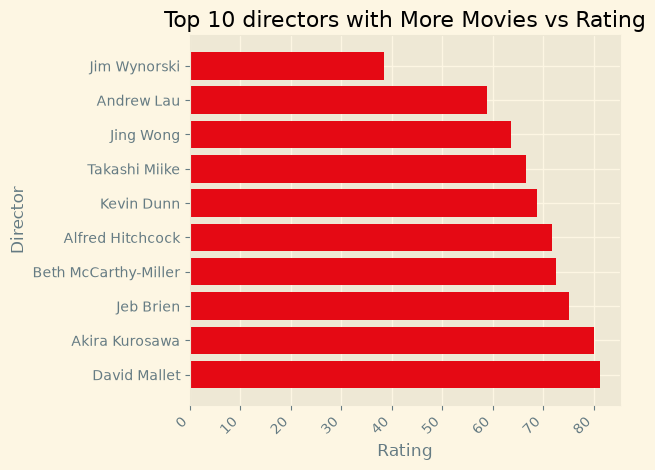

In [95]:
plt.barh(
    top10_directors_movies_avg_rat.director,
    top10_directors_movies_avg_rat.rating, color = color_Netflix)

plt.title('Top 10 directors with More Movies vs Rating')
plt.xlabel('Rating')
plt.ylabel('Director')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

David Mallet and Akira Kurosawa are the highest-rated, with averages above 80, reflecting strong critical and audience reception. In contrast, Kevin Dunn, who has the most titles, ranks only 6th, highlighting that quantity doesn’t always guarantee high ratings. The lowest average belongs to Jim Wynorski, whose large output appears to have limited viewer appreciation.

---

**ES**

David Mallet y Akira Kurosawa son los mejor calificados, con promedios superiores a 80, lo que refleja una fuerte recepción de la crítica y la audiencia. En contraste, Kevin Dunn, quien tiene más títulos, ocupa apenas el puesto 6, resaltando que la cantidad no siempre garantiza ratings altos. El promedio más bajo pertenece a Jim Wynorski, cuya gran producción parece tener una apreciación limitada por parte de los espectadores.

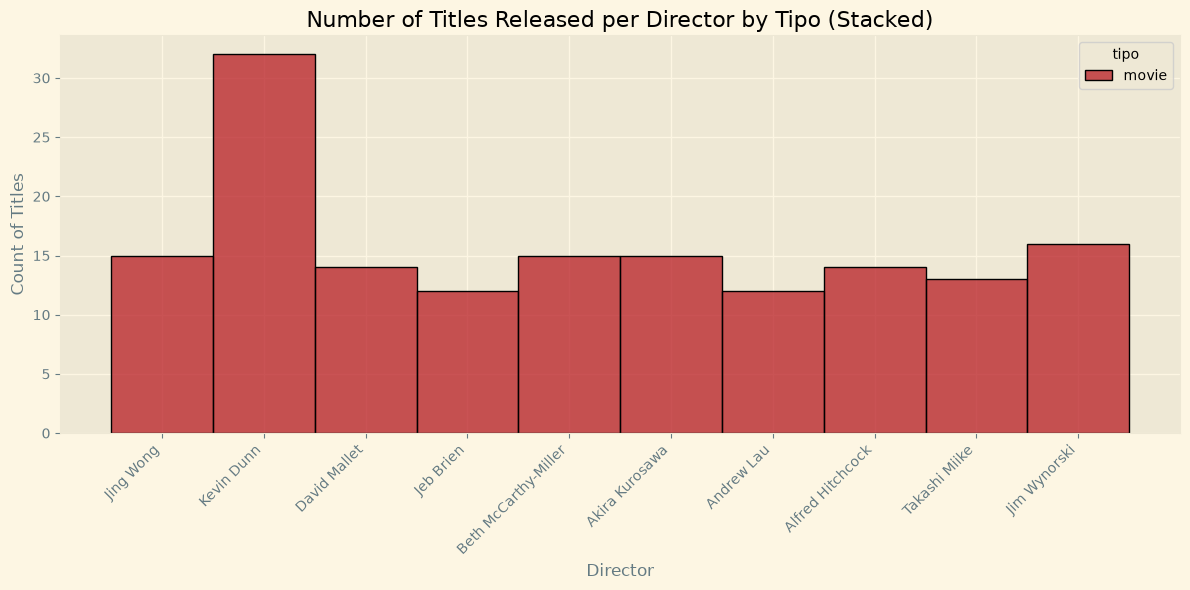

In [96]:
# Stacked bar for each director and type / ES: Barra apilada por director y tipo

plt.figure(figsize=(12, 6))
sns.histplot(data=top10_directors_movies, x='director',hue='tipo',multiple='stack', discrete=True, palette = color_netflix3)

plt.title('Number of Titles Released per Director by Tipo (Stacked)')
plt.xlabel('Director')
plt.ylabel('Count of Titles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The exclusive presence of movies emphasizes that these directors have focused heavily on the film format, aligning with Netflix’s dominant preference for movies in its content library.

---

**ES**

La presencia exclusiva de películas resalta que estos directores se han enfocado fuertemente en el formato cinematográfico, alineándose con la preferencia dominante de Netflix por las películas en su biblioteca de contenido.

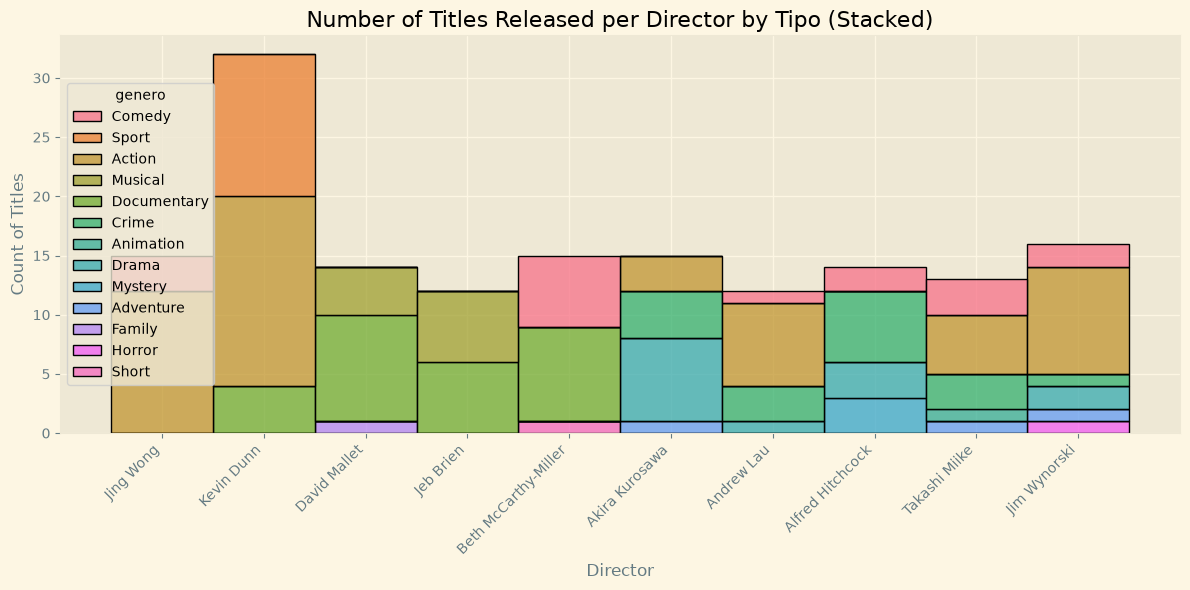

In [97]:
# Stacked bar for each director and genres / ES: Barra apilada por director y género

plt.figure(figsize=(12, 6))
sns.histplot(data=top10_directors_movies, x='director',hue='genero',multiple='stack', discrete=True) #palette = color_netflix3 )

plt.title('Number of Titles Released per Director by Tipo (Stacked)')
plt.xlabel('Director')
plt.ylabel('Count of Titles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This chart highlights how Kevin Dunn dominates Netflix’s director list not just in volume but also through a heavy focus on Sport and Action titles. Meanwhile, directors like David Mallet and Beth McCarthy-Miller stand out for their specialization in Documentaries and Musicals or Comedy. Akira Kurosawa and Takashi Miike demonstrate notable genre diversity, including Drama, Crime, and Animation. The overall trend shows that while some directors explore multiple genres, most maintain a consistent creative niche, shaping their contribution to Netflix’s content landscape.

---

**ES**

Este gráfico destaca cómo Kevin Dunn domina la lista de directores de Netflix no solo en volumen, sino también por un fuerte enfoque en títulos de Sport y Action. Mientras tanto, directores como David Mallet y Beth McCarthy-Miller destacan por su especialización en Documentaries y Musicals o Comedy. Akira Kurosawa y Takashi Miike muestran una notable diversidad de géneros, incluyendo Drama, Crime y Animation. La tendencia general muestra que, si bien algunos directores exploran múltiples géneros, la mayoría mantiene un nicho creativo consistente, definiendo su contribución al panorama de contenido de Netflix.

In [98]:
# Best Average rating per director. / ES: Mejor rating promedio por director.

best_avg_rating = (
    df
    .groupby('director')['rating']
    .mean()
    .reset_index()
    .sort_values('rating', ascending=False)
)

best_avg_rating = best_avg_rating.head(10).reset_index()


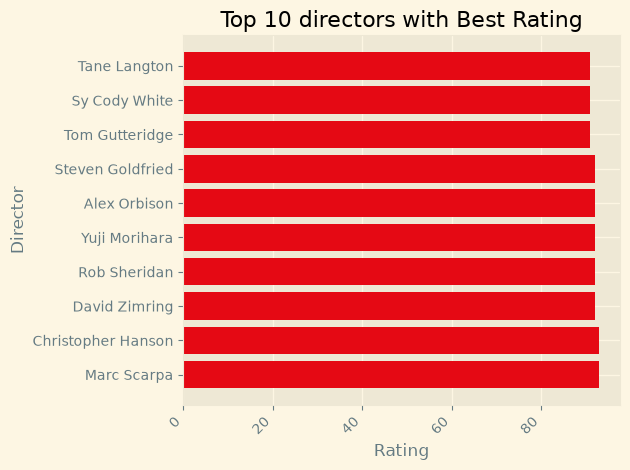

In [99]:
plt.barh(
    best_avg_rating.director,
    best_avg_rating.rating, color = color_Netflix)

plt.title('Top 10 directors with Best Rating')
plt.xlabel('Rating')
plt.ylabel('Director')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This chart highlights the top 10 highest-rated directors on Netflix, all with average ratings near 90, demonstrating exceptional audience approval. Unlike the most prolific directors, these individuals—such as Tane Langton, Sy Cody White, and Christopher Hanson—are likely responsible for fewer but highly praised titles, potentially in niche genres or specialized documentaries. Their presence suggests that critical success and viewer satisfaction don’t always align with fame or output volume, and that high-quality content can come from lesser-known creators.

---

**ES**

Este gráfico destaca a los 10 directores mejor calificados en Netflix, todos con ratings promedio cercanos a 90, demostrando una aprobación excepcional de la audiencia. A diferencia de los directores más prolíficos, estas personas —como Tane Langton, Sy Cody White y Christopher Hanson— probablemente son responsables de menos títulos, pero muy bien valorados, posiblemente en géneros de nicho o documentales especializados. Su presencia sugiere que el éxito crítico y la satisfacción del espectador no siempre van de la mano con la fama o el volumen de producción, y que el contenido de alta calidad puede venir de creadores menos conocidos.

In [100]:
#Creating a Data Frame of Directors with Best Rating / ES: Creando un DataFrame de directores con mejor rating

df_top10_directors_rating = df[df['director'].isin(best_avg_rating.director.tolist())]

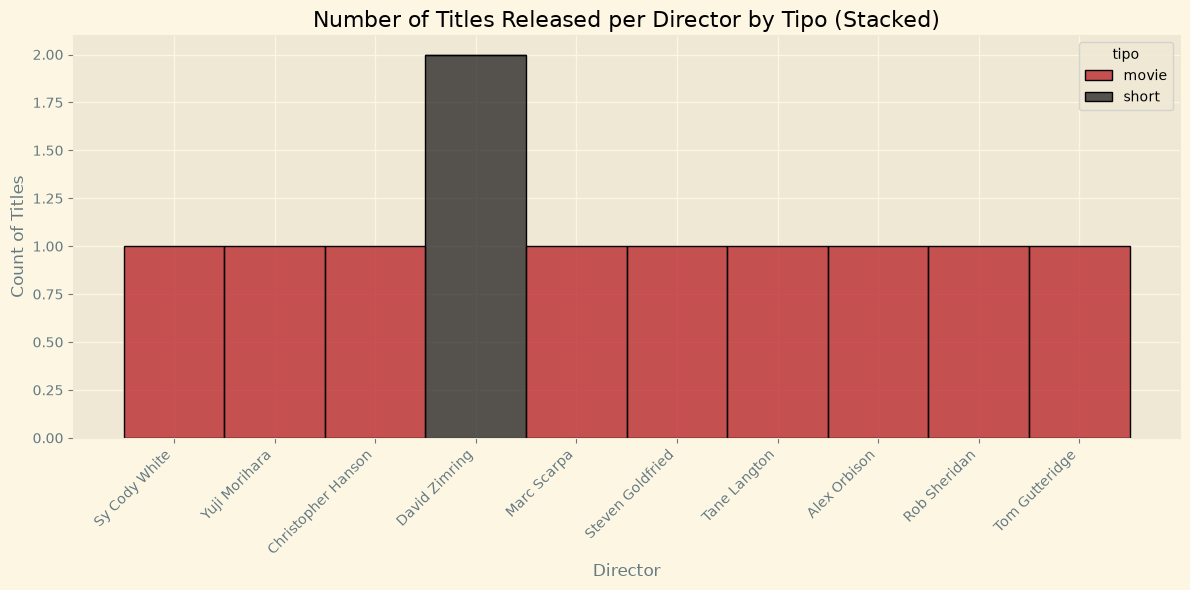

In [101]:
# Stacked bar for each director and type / ES: Barra apilada por director y tipo

plt.figure(figsize=(12, 6))
sns.histplot(data=df_top10_directors_rating, x='director',hue='tipo',multiple='stack', discrete=True, palette = color_netflix3)

plt.title('Number of Titles Released per Director by Tipo (Stacked)')
plt.xlabel('Director')
plt.ylabel('Count of Titles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This chart reveals that most of the top 10 highest-rated directors on Netflix owe their status to a single well-received movie, highlighting the impact one standout title can have. Only David Zimming has more than one title (two short films), showing that even limited-format content can achieve critical acclaim. However, the lack of volume suggests these directors' high ratings reflect individual successes, rather than a consistent track record across multiple projects.

---

**ES**

Este gráfico revela que la mayoría de los 10 directores mejor calificados en Netflix deben su posición a una sola película bien recibida, resaltando el impacto que puede tener un título destacado. Solo David Zimming tiene más de un título (dos cortometrajes), mostrando que incluso el contenido de formato limitado puede lograr reconocimiento crítico. Sin embargo, la falta de volumen sugiere que los ratings altos de estos directores reflejan éxitos individuales, más que una trayectoria consistente en múltiples proyectos.

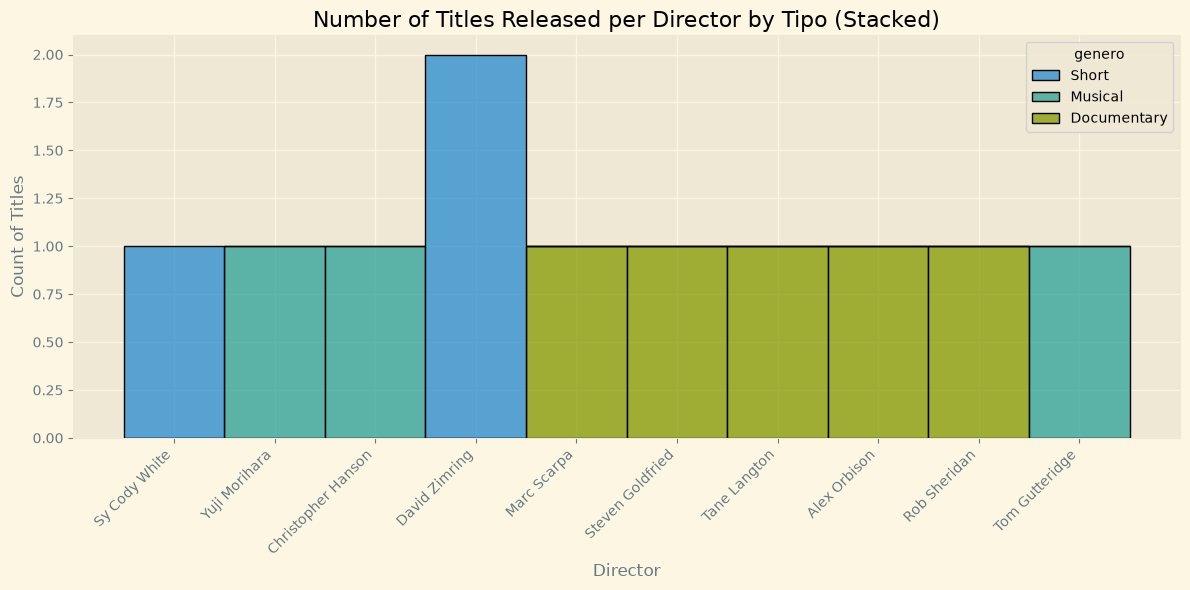

In [102]:
# Stacked bar for each director and genres / ES: Barra apilada por director y género

plt.figure(figsize=(12, 6))
sns.histplot(data=df_top10_directors_rating, x='director',hue='genero',multiple='stack', discrete=True) #palette = color_netflix3 )

plt.title('Number of Titles Released per Director by Tipo (Stacked)')
plt.xlabel('Director')
plt.ylabel('Count of Titles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This visualization highlights that the highest-rated directors on Netflix are mainly linked to documentaries, with five out of ten contributing to this genre. Others created musicals or short films, both of which are also genres known for high viewer satisfaction. Notably, David Zimming stands out for having two short films, while all others have just one title. The data suggests that quality over quantity, combined with impactful storytelling formats like documentaries and shorts, is a strong factor in achieving top ratings on the platform.

---

**ES**

Esta visualización resalta que los directores mejor calificados en Netflix están principalmente vinculados a documentales, con cinco de diez contribuyendo a este género. Otros crearon musicales o cortometrajes, ambos géneros también conocidos por su alta satisfacción del espectador. Cabe destacar que David Zimming se distingue por tener dos cortometrajes, mientras que todos los demás tienen un solo título. Los datos sugieren que la calidad sobre la cantidad, combinada con formatos narrativos impactantes como los documentales y los cortos, es un factor importante para lograr los ratings más altos en la plataforma.

## Key Insights

---

**ES**

## Hallazgos clave

1. Content Volume and Growth Trends
The number of Netflix titles peaked between 1995 and 2002, especially in 2002, with over 450 releases.

After 2002, the number of new titles dropped sharply, but there's a slight resurgence post-2010, likely due to the rise of Netflix Originals.

Early content (before 1980) represents a small fraction of the catalog, confirming a bias toward more modern productions.

2. Content Type Distribution
Movies dominate the platform, making up the majority of content across all years and countries.

Series, mini series, and short films are fewer but show growth in recent years.

Shorts and mini series tend to receive the highest average ratings, indicating quality over quantity.

3. Genre Preferences
The most common genres on Netflix are Comedy, Documentary, and Drama, each with over 1,100 titles.

Documentaries not only rank high in volume but also consistently receive high average ratings, making them both popular and critically successful.

Reality-TV, Mystery, Sport, and Fantasy are among the least represented genres.

Genre diversity has increased over time, especially after 2010, suggesting a strategy to target niche audiences.

4. Rating Behavior
Most highly-rated content lies in the 70–90 rating range, with very few titles below 50.

The rating distribution varies by content type:

Shorts and mini series have tighter, higher rating ranges.

Movies have the widest spread, indicating inconsistency in viewer satisfaction.

Documentaries again stand out as the top-rated genre among the top five.

5. Popularity vs. Quality
Titles with millions of votes tend to have high ratings, showing strong audience reception.

However, many well-rated titles have low vote counts, suggesting critically strong but lesser-known content exists.

Low-rated titles generally receive few votes, implying they’re also less watched or promoted.

6. Duration Patterns
Movies mostly range from 80–120 minutes, aligning with standard film length.

Mini series and series show much wider variation, with some extending over 1,000 minutes.

Short films are generally under 50 minutes, as expected.

7. Top Countries and Languages
The United States dominates Netflix’s catalog, with over 3,500 titles, followed distantly by the UK, Japan, India, and Canada.

In terms of language, English accounts for more than 4,500 titles, vastly surpassing other languages like Japanese, Hindi, Cantonese, and French.

Despite growing international content, Netflix is still heavily rooted in Anglophone media.

8. Directors: Volume vs. Quality
Kevin Dunn is the most prolific director (30+ titles), mainly in sports and action, but has moderate ratings.

David Mallet and Akira Kurosawa have the highest average ratings among the most prolific directors.

Jim Wynorski shows that high volume doesn't guarantee high ratings, with the lowest average in the top 10.

The top-rated directors overall (Tane Langton, Sy Cody White, etc.) have only one or two titles, mostly documentaries, musicals, or shorts, emphasizing that smaller, focused projects can outperform larger portfolios in quality.


Overall Conclusion

Netflix’s content strategy is clearly built on a strong foundation of movies and English-language titles, particularly from the U.S., but it is evolving toward greater genre diversity and international inclusion. Documentaries and short-form content emerge as consistently high-performing formats, even though they’re less prevalent. While popularity and rating often align, many hidden gems exist—especially in genres like documentary and musical—directed by lesser-known filmmakers. Netflix's catalog reflects a platform in transition, balancing mainstream appeal with an increasing emphasis on niche, quality-driven storytelling.

---

**ES**

1. Volumen de contenido y tendencias de crecimiento
El número de títulos de Netflix alcanzó su punto máximo entre 1995 y 2002, especialmente en 2002, con más de 450 lanzamientos.

Después de 2002, el número de títulos nuevos cayó drásticamente, pero hay un ligero repunte después de 2010, probablemente debido al auge de los Netflix Originals.

El contenido antiguo (anterior a 1980) representa una fracción pequeña del catálogo, confirmando un sesgo hacia producciones más modernas.

2. Distribución por tipo de contenido
Las películas dominan la plataforma, representando la mayoría del contenido en todos los años y países.

Las series, mini series y cortometrajes son menos numerosos, pero muestran crecimiento en los últimos años.

Los shorts y las mini series tienden a recibir los ratings promedio más altos, lo que indica calidad sobre cantidad.

3. Preferencias de género
Los géneros más comunes en Netflix son Comedy, Documentary y Drama, cada uno con más de 1,100 títulos.

Los documentales no solo destacan en volumen, sino que también reciben consistentemente ratings promedio altos, siendo populares y exitosos ante la crítica a la vez.

Reality-TV, Mystery, Sport y Fantasy están entre los géneros menos representados.

La diversidad de géneros ha aumentado con el tiempo, especialmente después de 2010, sugiriendo una estrategia para dirigirse a audiencias de nicho.

4. Comportamiento de los ratings
La mayoría del contenido mejor calificado está en el rango de rating de 70 a 90, con muy pocos títulos por debajo de 50.

La distribución de ratings varía según el tipo de contenido:

Los shorts y las mini series tienen rangos de rating más estrechos y altos.

Las películas tienen la dispersión más amplia, lo que indica inconsistencia en la satisfacción del espectador.

Los documentales vuelven a destacar como el género mejor calificado entre los cinco principales.

5. Popularidad vs. calidad
Los títulos con millones de votos tienden a tener ratings altos, mostrando una fuerte recepción de la audiencia.

Sin embargo, muchos títulos bien calificados tienen pocos votos, lo que sugiere que existe contenido crítico fuerte pero poco conocido.

Los títulos con rating bajo generalmente reciben pocos votos, lo que implica que también son menos vistos o promocionados.

6. Patrones de duración
Las películas van mayormente de 80 a 120 minutos, alineándose con la duración estándar de un largometraje.

Las mini series y series muestran una variación mucho mayor, algunas superando los 1,000 minutos.

Los cortometrajes generalmente duran menos de 50 minutos, como era de esperar.

7. Principales países e idiomas
Estados Unidos domina el catálogo de Netflix, con más de 3,500 títulos, seguido a distancia por el Reino Unido, Japón, India y Canadá.

En cuanto a idioma, el inglés representa más de 4,500 títulos, superando ampliamente a otros idiomas como japonés, hindi, cantonés y francés.

A pesar del creciente contenido internacional, Netflix sigue fuertemente arraigado en los medios anglófonos.

8. Directores: volumen vs. calidad
Kevin Dunn es el director más prolífico (30+ títulos), principalmente en deportes y acción, pero con ratings moderados.

David Mallet y Akira Kurosawa tienen los ratings promedio más altos entre los directores más prolíficos.

Jim Wynorski demuestra que un volumen alto no garantiza ratings altos, con el promedio más bajo del top 10.

Los directores mejor calificados en general (Tane Langton, Sy Cody White, etc.) tienen solo uno o dos títulos, en su mayoría documentales, musicales o cortometrajes, resaltando que proyectos más pequeños y enfocados pueden superar en calidad a portafolios más grandes.


Conclusión general

La estrategia de contenido de Netflix está claramente construida sobre una base sólida de películas y títulos en inglés, particularmente de EE. UU., pero está evolucionando hacia una mayor diversidad de géneros e inclusión internacional. Los documentales y el contenido de formato corto surgen como formatos consistentemente exitosos, aunque son menos frecuentes. Si bien la popularidad y el rating suelen alinearse, existen muchas joyas ocultas —especialmente en géneros como documental y musical— dirigidas por cineastas menos conocidos. El catálogo de Netflix refleja una plataforma en transición, equilibrando el atractivo masivo con un énfasis creciente en la narrativa de nicho orientada a la calidad.

## Recommendations

---

**ES**

## Recomendaciones

Business & Production Insights
Prioritize High-Rated Formats
The consistently high ratings of documentaries, mini series, and shorts suggest a strategic opportunity. Netflix could:

Invest more in short-form and docu-style storytelling, especially from emerging filmmakers.

Promote these formats more prominently in the platform’s UI to surface under-watched but high-quality content.

Balance Quantity with Quality
While movies dominate in volume, they also show the most variability in quality. Netflix should:

Focus on curation and quality control for movie acquisitions.

Use rating trends to optimize recommendation algorithms, highlighting movies with better reception over just recent releases.

Elevate International and Non-English Content
Although English content dominates, the presence of highly-rated Japanese, Hindi, and French content indicates:

A growth opportunity in localized content, especially for expanding global market share.

Netflix can increase investment in regional originals and cross-cultural co-productions to strengthen international appeal.

Leverage Top-Rated Creators
Several lesser-known directors with extremely high ratings have only released one or two titles:

Netflix could identify these creators as hidden gems and consider exclusive multi-project deals.

This would enable the platform to build loyalty and differentiate its catalog through high-quality original content.

Re-evaluate Content Discovery Algorithms
Many highly-rated titles receive very few votes, indicating they may not be getting sufficient exposure.

---

**ES**

Perspectivas de negocio y producción
Priorizar los formatos mejor calificados
Los ratings consistentemente altos de documentales, mini series y cortometrajes sugieren una oportunidad estratégica. Netflix podría:

Invertir más en narrativa de formato corto y estilo documental, especialmente de cineastas emergentes.

Promover estos formatos de forma más visible en la interfaz de la plataforma para dar visibilidad a contenido de alta calidad pero poco visto.

Equilibrar cantidad con calidad
Aunque las películas dominan en volumen, también muestran la mayor variabilidad en calidad. Netflix debería:

Enfocarse en la curaduría y el control de calidad de las adquisiciones de películas.

Usar las tendencias de rating para optimizar los algoritmos de recomendación, destacando películas con mejor recepción por encima de solo los lanzamientos recientes.

Impulsar el contenido internacional y no anglófono
Aunque el contenido en inglés domina, la presencia de contenido japonés, hindi y francés muy bien calificado indica:

Una oportunidad de crecimiento en contenido localizado, especialmente para expandir la participación de mercado global.

Netflix puede aumentar la inversión en producciones originales regionales y coproducciones interculturales para fortalecer su atractivo internacional.

Aprovechar a los creadores mejor calificados
Varios directores menos conocidos con ratings extremadamente altos solo han lanzado uno o dos títulos:

Netflix podría identificar a estos creadores como joyas ocultas y considerar acuerdos exclusivos de múltiples proyectos.

Esto permitiría a la plataforma construir lealtad y diferenciar su catálogo mediante contenido original de alta calidad.

Reevaluar los algoritmos de descubrimiento de contenido
Muchos títulos bien calificados reciben muy pocos votos, lo que indica que podrían no estar recibiendo suficiente exposición.